# Step 3 & 4 — Feature Engineering & Exploratory Data Analysis
Derive efficiency metrics, build correlation matrix, and visualize trends.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
sns.set_palette('Set2')

os.makedirs('../outputs', exist_ok=True)

df = pd.read_csv('../data/ai_datacenter_master_clean.csv')
print(f"Loaded: {df.shape}")

Loaded: (50, 15)


## Feature Engineering

In [2]:
df['energy_waste_pct'] = (df['pue'] - 1) / df['pue'] * 100
df['energy_wasted_gwh'] = df['electricity_gwh'] - df['it_load_gwh']
df['renewable_gap_pct'] = df['renewable_pledged_pct'] - df['renewable_actual_pct']
df['co2_per_gwh'] = df['co2_tons'] / df['electricity_gwh']
df['water_per_million_queries'] = df['water_litres'] / df['queries_million']
df['water_per_query_ml'] = (df['water_litres'] / (df['queries_million'] * 1e6)) * 1000

print("New columns added:")
print([c for c in df.columns if c not in pd.read_csv('../data/ai_datacenter_master_clean.csv').columns])
df.head()

New columns added:
['energy_waste_pct', 'energy_wasted_gwh', 'renewable_gap_pct', 'co2_per_gwh', 'water_per_million_queries', 'water_per_query_ml']


,company,year,electricity_gwh,it_load_gwh,water_litres,water_consumed_litres,pue,wue,cue,co2_tons,...,renewable_actual_pct,queries_million,region,facility_count,energy_waste_pct,energy_wasted_gwh,renewable_gap_pct,co2_per_gwh,water_per_million_queries,water_per_query_ml
0,Google,2015,7.81,6.99,1858291968,1080046220,1.119,266.000,393.7010,3076671,...,34,811.2,Europe,15,10.634495,0.82,3,393939.948784,2.290794e+06,2290.793846
1,Google,2016,9.04,8.13,2070690052,1214180159,1.113,254.845,294.5228,2663697,...,40,900.4,Europe,17,10.152740,0.91,4,294656.747788,2.299745e+06,2299.744616
2,Google,2017,9.49,8.55,2143575418,1304213297,1.110,250.733,273.4351,2594650,...,50,1074.7,Europe,19,9.909910,0.94,6,273408.851423,1.994580e+06,1994.580272
3,Google,2018,10.68,9.58,2348720224,1570079339,1.114,245.090,226.7284,2420469,...,58,1280.6,North America,21,10.233393,1.10,9,226635.674157,1.834078e+06,1834.077951
4,Google,2019,12.77,11.52,2747123118,1577968526,1.108,238.386,190.4309,2431927,...,61,1509.6,Asia-Pacific,23,9.747292,1.25,12,190440.642130,1.819769e+06,1819.768891


## Correlation Heatmap

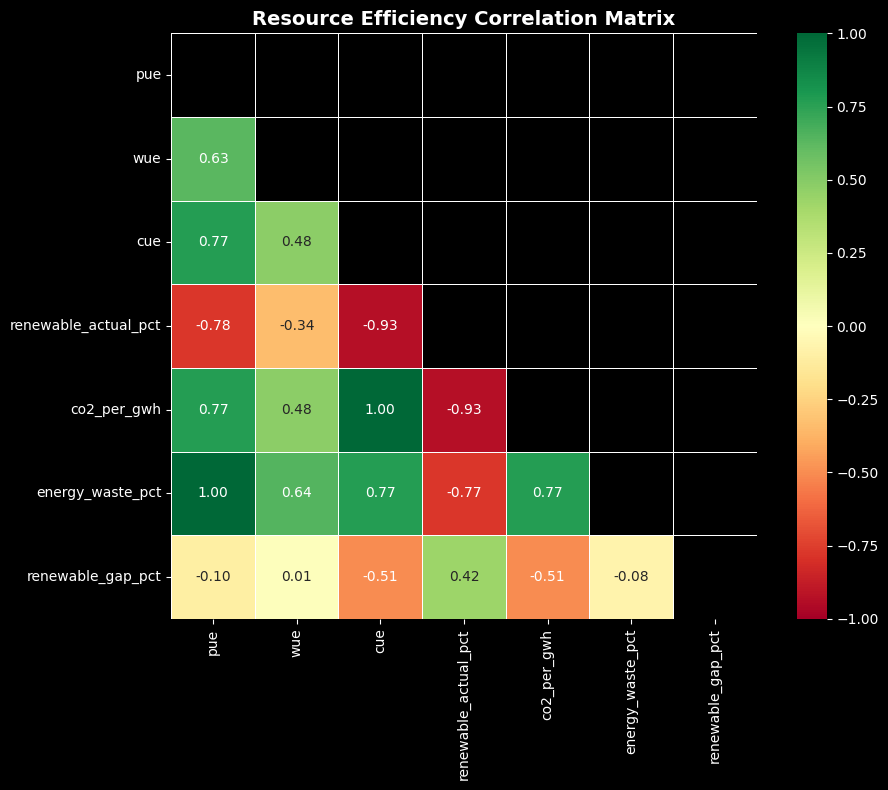

In [3]:
numeric_cols = ['pue', 'wue', 'cue', 'renewable_actual_pct',
                'co2_per_gwh', 'energy_waste_pct', 'renewable_gap_pct']

company_df = df[df['company'] != 'All']

fig, ax = plt.subplots(figsize=(10, 8))
corr = company_df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, mask=mask,
            square=True, linewidths=0.5)
ax.set_title('Resource Efficiency Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## PUE Over Time by Company

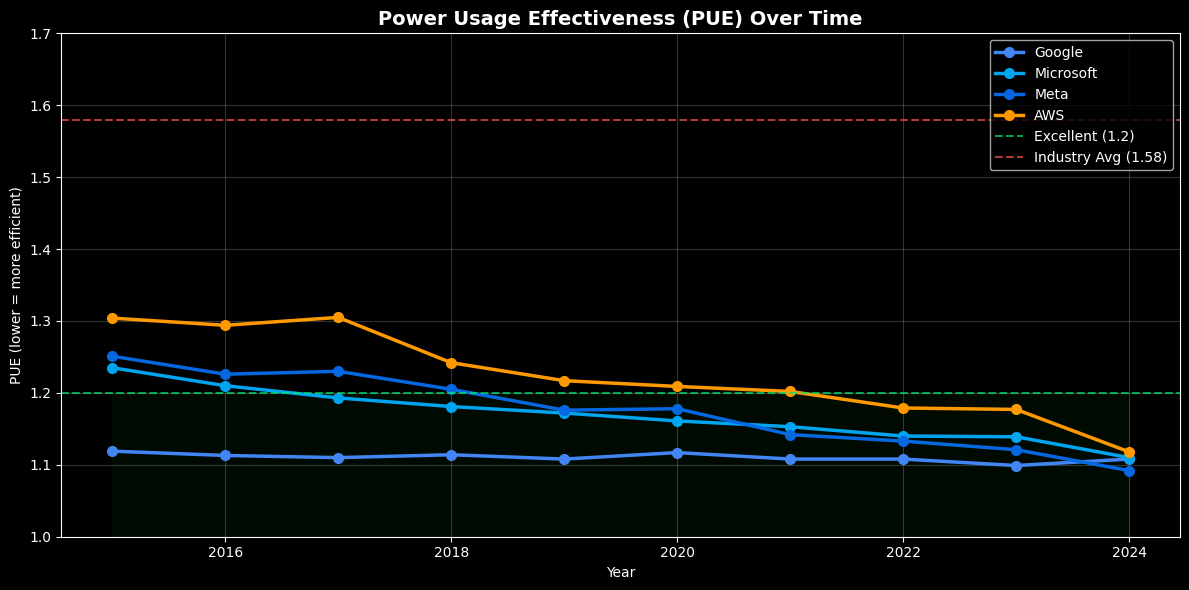

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = {'Google': '#4285F4', 'Microsoft': '#00A4EF', 'Meta': '#0668E1', 'AWS': '#FF9900'}

for company in ['Google', 'Microsoft', 'Meta', 'AWS']:
    subset = company_df[company_df['company'] == company].sort_values('year')
    ax.plot(subset['year'], subset['pue'], marker='o', label=company,
            linewidth=2.5, color=colors[company], markersize=7)

ax.axhline(y=1.2, color='#00e676', linestyle='--', alpha=0.7, label='Excellent (1.2)')
ax.axhline(y=1.58, color='#ff5252', linestyle='--', alpha=0.7, label='Industry Avg (1.58)')
ax.fill_between([2015, 2024], 1.0, 1.2, alpha=0.08, color='green')
ax.set_title('Power Usage Effectiveness (PUE) Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('PUE (lower = more efficient)')
ax.legend(loc='upper right')
ax.set_ylim(1.0, 1.7)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('../outputs/pue_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## Energy Waste by Company

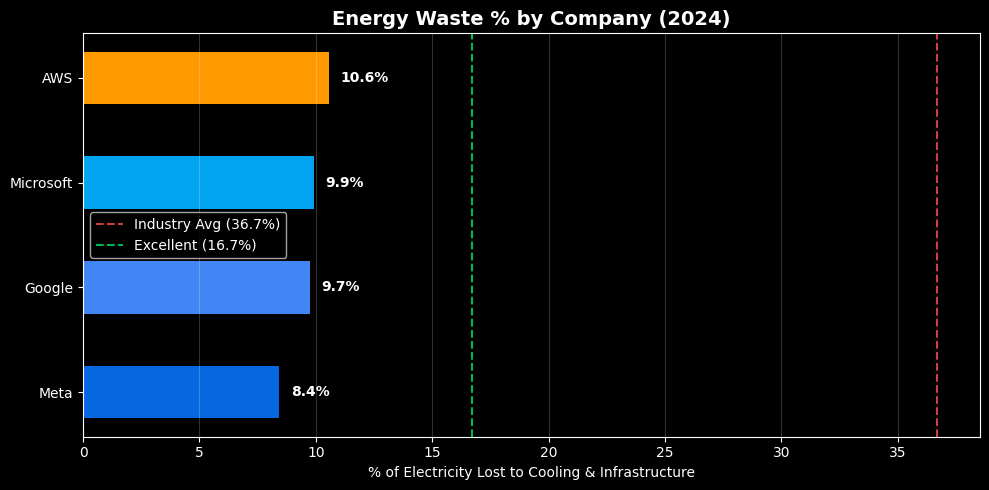

In [5]:
latest = company_df[company_df['year'] == 2024].sort_values('energy_waste_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(latest['company'], latest['energy_waste_pct'],
               color=[colors[c] for c in latest['company']], height=0.5)
ax.axvline(x=36.7, color='#ff5252', linestyle='--', alpha=0.8, label='Industry Avg (36.7%)')
ax.axvline(x=16.7, color='#00e676', linestyle='--', alpha=0.8, label='Excellent (16.7%)')

for bar, val in zip(bars, latest['energy_waste_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold')

ax.set_title('Energy Waste % by Company (2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('% of Electricity Lost to Cooling & Infrastructure')
ax.legend()
ax.grid(alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig('../outputs/energy_waste_bars.png', dpi=150, bbox_inches='tight')
plt.show()

## Renewable Pledge vs Reality

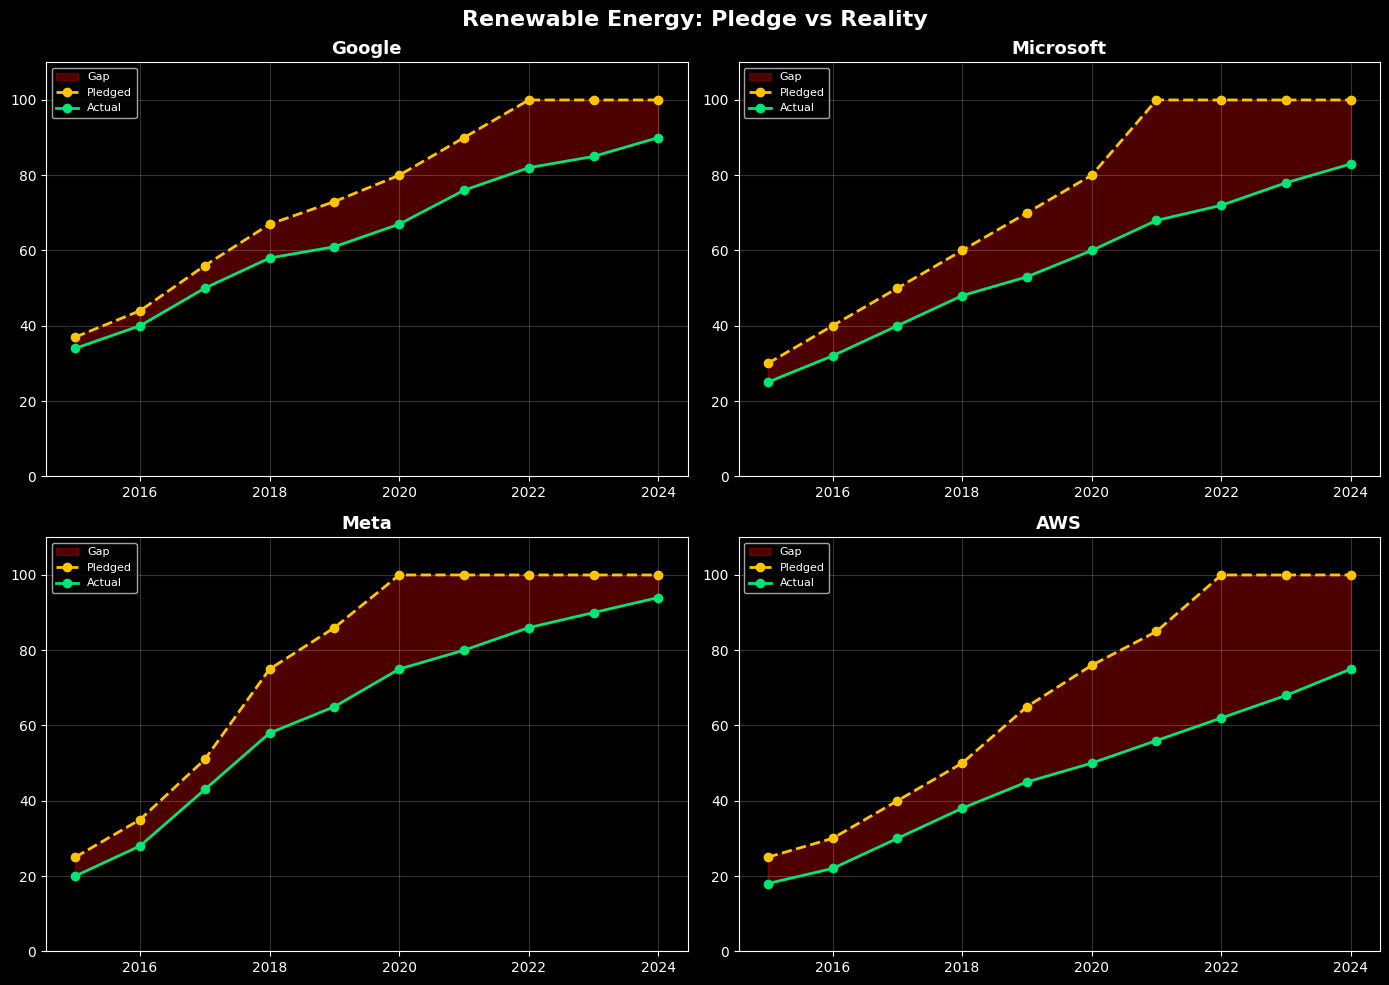

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, company in zip(axes.flat, ['Google', 'Microsoft', 'Meta', 'AWS']):
    subset = company_df[company_df['company'] == company].sort_values('year')
    ax.fill_between(subset['year'], subset['renewable_pledged_pct'],
                    subset['renewable_actual_pct'], alpha=0.3, color='red', label='Gap')
    ax.plot(subset['year'], subset['renewable_pledged_pct'], 'o--',
            color='#ffc400', label='Pledged', linewidth=2)
    ax.plot(subset['year'], subset['renewable_actual_pct'], 'o-',
            color='#00e676', label='Actual', linewidth=2)
    ax.set_title(company, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 110)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

fig.suptitle('Renewable Energy: Pledge vs Reality', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/renewable_gap.png', dpi=150, bbox_inches='tight')
plt.show()

## Electricity Growth Over Time

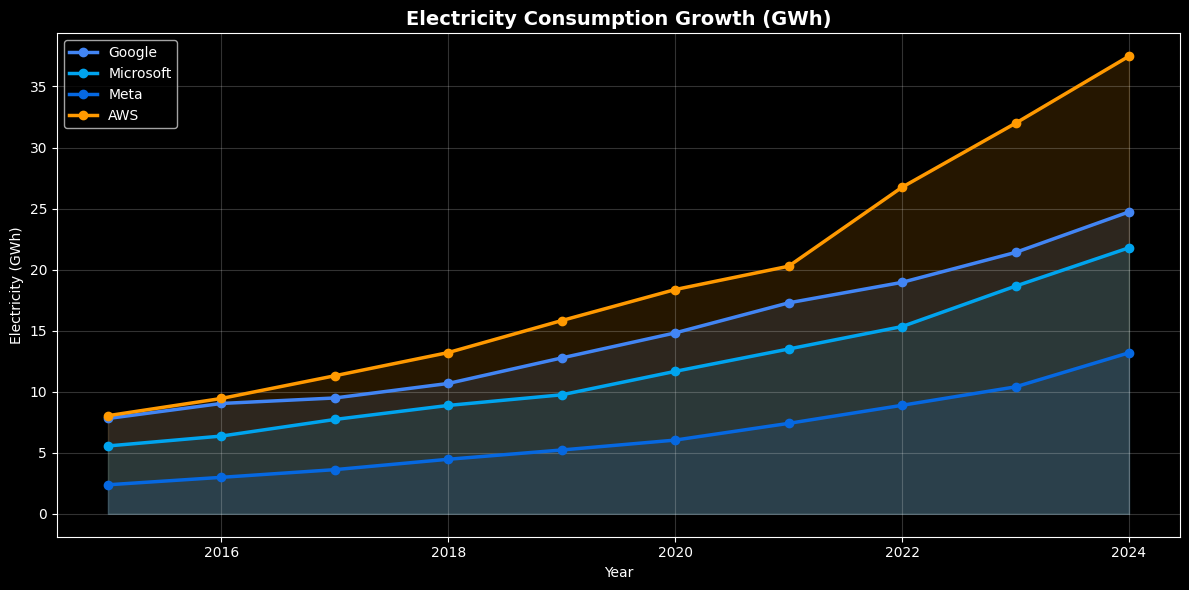

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

for company in ['Google', 'Microsoft', 'Meta', 'AWS']:
    subset = company_df[company_df['company'] == company].sort_values('year')
    ax.fill_between(subset['year'], 0, subset['electricity_gwh'],
                    alpha=0.15, color=colors[company])
    ax.plot(subset['year'], subset['electricity_gwh'], 'o-',
            color=colors[company], label=company, linewidth=2.5)

ax.set_title('Electricity Consumption Growth (GWh)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Electricity (GWh)')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('../outputs/electricity_growth.png', dpi=150, bbox_inches='tight')
plt.show()

## CO2 Emissions Trend

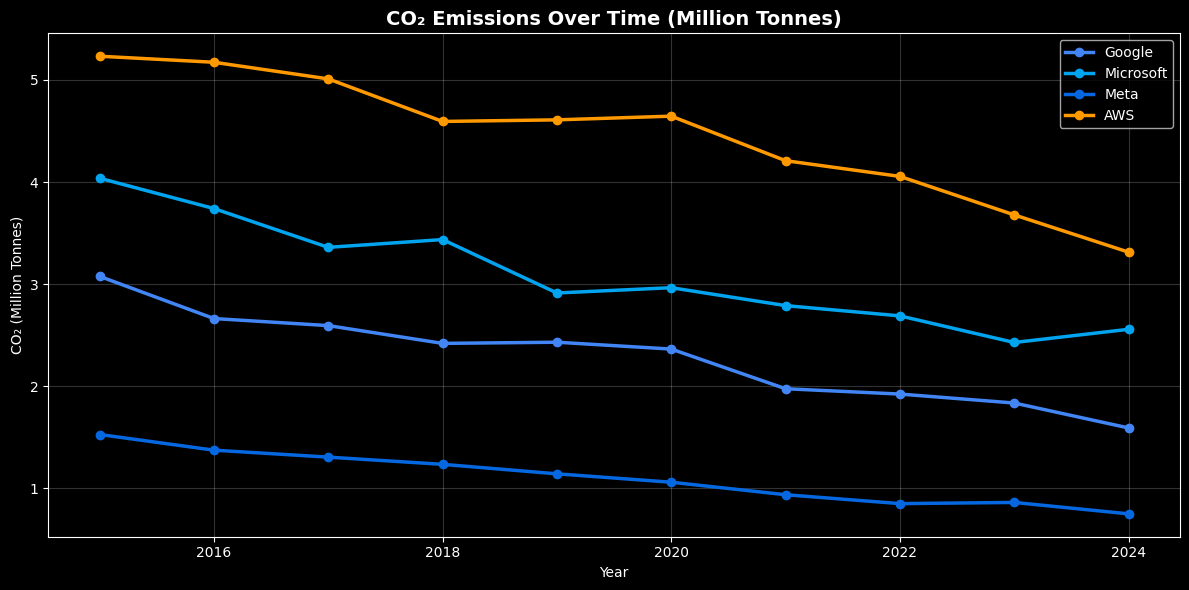

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

for company in ['Google', 'Microsoft', 'Meta', 'AWS']:
    subset = company_df[company_df['company'] == company].sort_values('year')
    ax.plot(subset['year'], subset['co2_tons'] / 1e6, 'o-',
            color=colors[company], label=company, linewidth=2.5)

ax.set_title('CO₂ Emissions Over Time (Million Tonnes)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('CO₂ (Million Tonnes)')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('../outputs/co2_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## Scatter: Capacity vs Efficiency

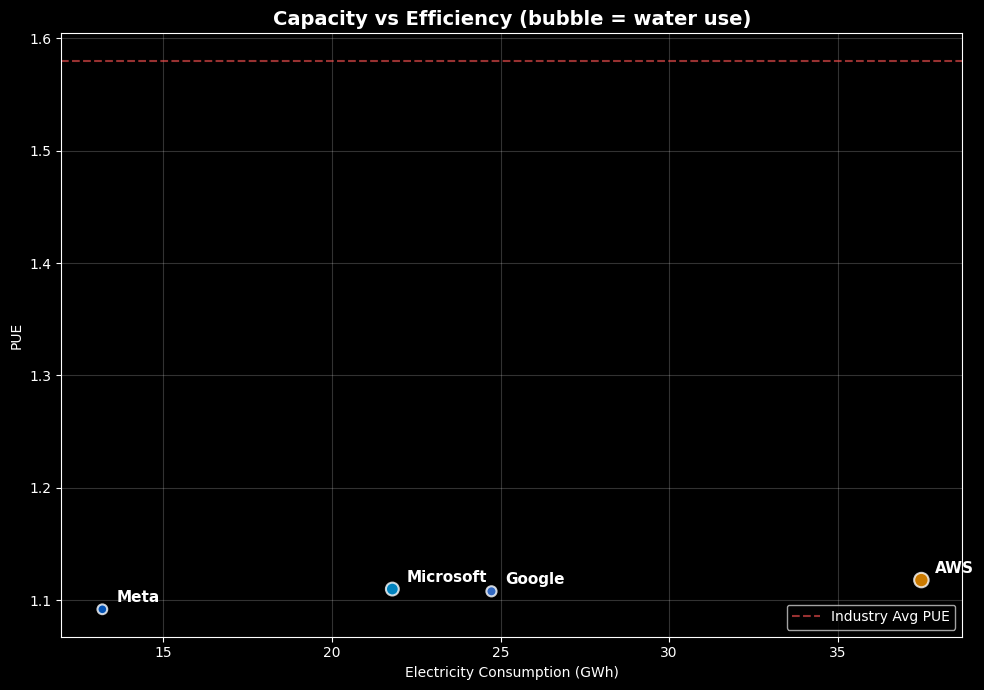

In [9]:
latest = company_df[company_df['year'] == 2024]

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(latest['electricity_gwh'], latest['pue'],
                     s=latest['water_litres'] / 1e8,
                     c=[list(colors.values())[list(colors.keys()).index(c)] for c in latest['company']],
                     alpha=0.8, edgecolors='white', linewidth=1.5)

for _, row in latest.iterrows():
    ax.annotate(row['company'], (row['electricity_gwh'], row['pue']),
                fontsize=11, fontweight='bold',
                xytext=(10, 5), textcoords='offset points')

ax.axhline(y=1.58, color='#ff5252', linestyle='--', alpha=0.6, label='Industry Avg PUE')
ax.set_title('Capacity vs Efficiency (bubble = water use)', fontsize=14, fontweight='bold')
ax.set_xlabel('Electricity Consumption (GWh)')
ax.set_ylabel('PUE')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('../outputs/capacity_vs_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Save enriched dataset
df.to_csv('../data/ai_datacenter_enriched.csv', index=False)
print("Saved: data/ai_datacenter_enriched.csv")

Saved: data/ai_datacenter_enriched.csv
